# Delta-hedged short straddle — walkthrough

Harvesting the **variance risk premium**: sell a rolling 1-month ATM SPX straddle priced off VIX and delta-hedge it daily. Implied vol (what you sell) systematically exceeds realized (what you pay out), so selling it — with direction hedged away — earns a premium. Mirrors `scripts/run_straddle.py`.

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import pandas as pd
import matplotlib.pyplot as plt

from quantbt import metrics, plotting
from quantbt.strategies.short_vol import short_straddle

## 1. Load SPX and VIX
`^GSPC` is the underlying; `^VIX` is the implied vol we price the straddle off.

In [2]:
px = pd.read_csv('data/spx_vix.csv', index_col=0, parse_dates=True)
spx, vix = px['^GSPC'], px['^VIX']
px.tail(3)

,^GSPC,^VIX
Date,,
2024-12-26,6037.589844,14.73
2024-12-27,5970.839844,15.95
2024-12-30,5906.939941,17.40


## 2. Run the strategy (after costs)
Each cycle we sell an ATM straddle, hold to expiry, and rehedge delta daily. Costs: a 1 vol-point option bid-ask paid on the sale, plus 0.5bp on each hedge.

In [3]:
res = short_straddle(spx, vix)
pd.Series(metrics.summarize(res.returns)).round(3)

ann_return      0.088
ann_vol         0.053
sharpe          1.621
sortino         1.961
max_drawdown   -0.135
hit_rate        0.701
dtype: float64

## 3. Cost-sensitivity sweep
How much edge survives a wider option bid-ask? It holds up even at 2 vol points.

In [4]:
sweep = {f'{s:g} vol-pt': metrics.summarize(short_straddle(spx, vix, option_spread_vol_pts=s).returns)
         for s in (0.0, 0.5, 1.0, 2.0)}
pd.DataFrame(sweep).T[['ann_return', 'sharpe', 'max_drawdown']].round(3)

,ann_return,sharpe,max_drawdown
0 vol-pt,0.103,1.889,-0.133
0.5 vol-pt,0.095,1.756,-0.134
1 vol-pt,0.088,1.621,-0.135
2 vol-pt,0.073,1.347,-0.137


## 4. Tail risk — the catch
The Sharpe flatters a short-insurance strategy. Skew is sharply negative and kurtosis is huge: rare, severe loss days are the price of the premium.

In [5]:
pd.Series(metrics.tail_stats(res.returns)).round(4)

skew               -4.5699
excess_kurtosis    55.4318
worst_day          -0.0558
var_95             -0.0039
cvar_95            -0.0092
var_99             -0.0116
cvar_99            -0.0200
dtype: float64

## 5. P&L decomposition
The short option leg collects premium (theta) but bleeds on big moves (gamma); the hedge removes direction; costs are the drag. They sum to the total.

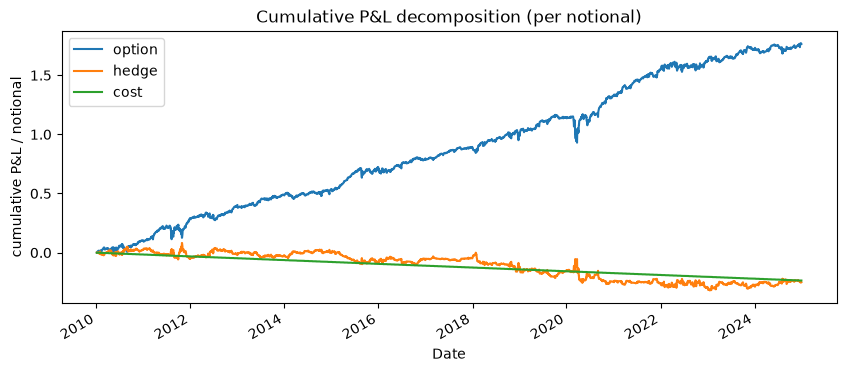

In [6]:
res.pnl[['option', 'hedge', 'cost']].cumsum().plot(
    figsize=(10, 4), title='Cumulative P&L decomposition (per notional)')
plt.ylabel('cumulative P&L / notional');

## 6. Tearsheet

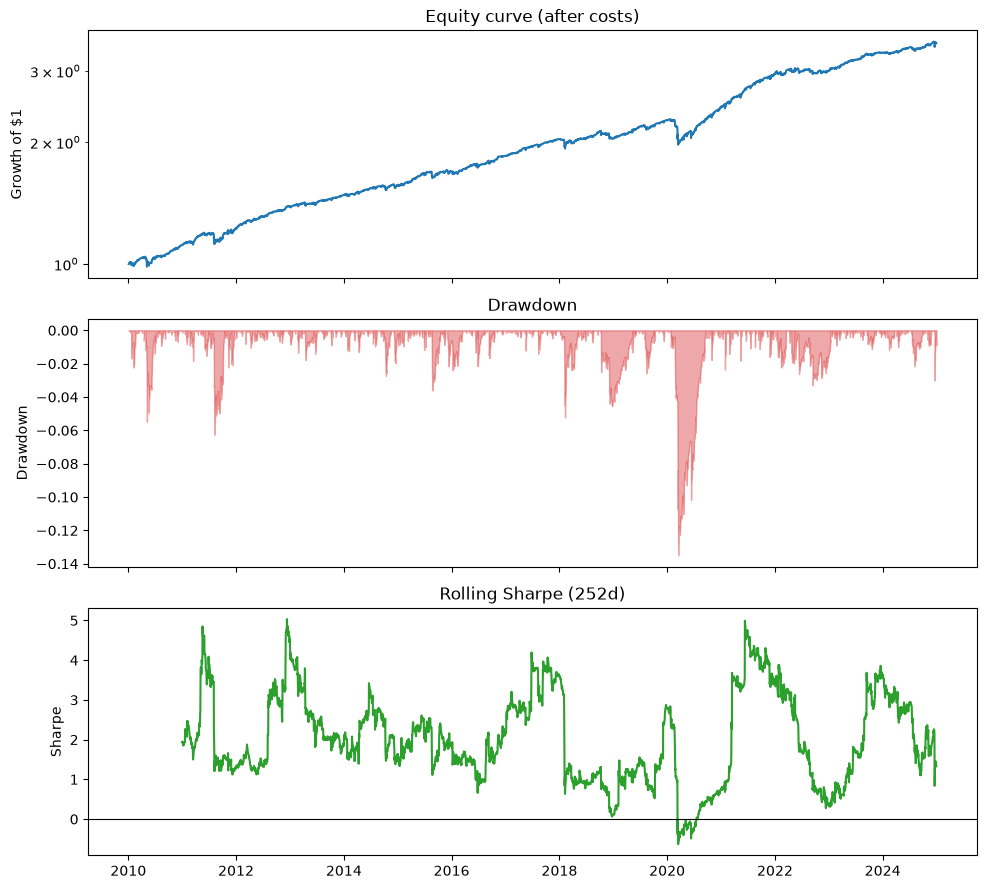

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
plotting.plot_equity(res.equity, ax=axes[0])
plotting.plot_drawdown(res.equity, ax=axes[1])
plotting.plot_rolling_sharpe(res.returns, ax=axes[2])
fig.tight_layout()

## Takeaway
The one strategy here that earns a real, durable premium — Sharpe ~1.4–1.6 after costs, robust to the assumed spread. But it is **selling insurance**: strongly left-skewed with fat tails, and the drawdowns cluster in Feb 2018 and March 2020. The premium is real and so is the tail, which is exactly why it pays. Caveat: options are priced synthetically off VIX (no real option chain), so the headline is optimistic versus a live implementation paying real option spreads.